In [ ]:
#!/usr/bin/env python3
# coding: utf-8

"""
File: spam_tuner_ga.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Mar-12

References:  Sections of this code were enhanced with the assistance of ChatGPT made by OpenAI. This script
    will tune the SPAM hyperparameters so they are able to produce SPAM orbits
    that are similar to the TNG orbits.  We hypothesize that if the SPAM orbits 
    match the TNG orbits, then the tidal features SPAM is able to produce will 
    more accurately resemble and recreate the TNG tidal features.

Description:  This file uses a genetic algorithm to optimize the hyper parameters of the SPAM Simulator using
    known artificial targets from the IllustrisTNG cosmological simulation.
"""

# ================================ STANDARD IMPORTS ================================ #
import logging
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================ PROJECT MODULES ================================ #
# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# import project modules
import utilities.general_utility as gu
import utilities.parallel_queue_manager as qm
import Optimization_Methods.optimization_manager as om
import IllustrisTNG.compare_tng_to_spam as cts

# ================================ GLOBAL VARIABLES ================================ #
buildEnv = False

# Global logger from main program
logger = gu.configure_logger()

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-9cln833r because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [1]:
# Development Cell:  This should only be present in the Jupyter Notebook version of this script for development purposes.
buildEnv = True

from importlib import reload

# Warn user if NOT in jupyter notebook, require a yes/no response to continue or not
if "ipykernel" not in sys.modules:
    msg = "Development Environment Detected.  This will run several tests and attempt to creat plots.  Do you want to continue?..."

    # Get user input
    while True:
        response = input(f"{msg} (y/n): ").lower()
        if response in ['y', 'yes']:
            break
        elif response in ['n', 'no']:
            print("Exiting...")
            sys.exit()
        else:
            print("Invalid input. Please enter 'y' or 'n'.")



NameError: name 'sys' is not defined

In [ ]:
if buildEnv:
    p1 = 62000000190717
    p2 = 75000000121160
    spam_loc = "/home/mbo2d/galStuff/data/misc_spam_orbits"

    logger.setLevel(logging.INFO)

    t1 = spam_tuner.DEV_SPAM_TNG_Tuner( p1, )

    orbit = t1.simulate_orbit( orbit_data={}, save_dir=spam_loc )
    weight_func = t1.gen_orbit_weights( boundary_value=0.1, scale_past=0.5 )
    
    print(f"Orbit: {type(orbit)}")
    print(f"Orbit: {[type(orbit[i]) for i in range(len(orbit))]}")
    print(f"Orbit: {orbit[0].shape}")
    print(f"Orbit: {orbit[1].keys()}")

    print(f"Weight Func: {type(weight_func)}")
    score = t1.weighted_avg_error_sq_over_by_time( orbit[0], weight_func )
    print(f"Score: {score}")


[2025-03-12 16:19:12,184 - INFO - convert_tng_to_spam.__init__]: Initializing TNG Target Class...


[2025-03-12 16:19:15,060 - INFO - spam_tuner_tng_targets.spam_tuner.simulate_orbit]: Simulating SPAM Orbit
[2025-03-12 16:19:15,060 - INFO - spam_tuner_tng_targets.simulate_orbit]: Simulating SPAM Orbit
[2025-03-12 16:19:15,064 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-12 16:19:15,077 - INFO - new_simulator.get_spam_parameters]: Querying SPAM Parameters
[2025-03-12 16:19:15,079 - INFO - spam_tuner_tng_targets.spam_tuner.simulate_orbit]: Loading Orbit: /home/mbo2d/galStuff/data/misc_spam_orbits/d54948b9d70a95bd9d3f3b2543e19a7d.npz
[2025-03-12 16:19:15,079 - INFO - spam_tuner_tng_targets.simulate_orbit]: Loading Orbit: /home/mbo2d/galStuff/data/misc_spam_orbits/d54948b9d70a95bd9d3f3b2543e19a7d.npz
[2025-03-12 16:19:15,082 - INFO - spam_tuner_tng_targets.spam_tuner.weighted_avg_error_sq_over_by_time]: Score Function for Orbit Similarity by Time
[2025-03-12 16:19:15,082 - INFO - spam_tuner_tng_targets.weighted_avg_error_sq_over_by_time]: Score Function

Orbit: <class 'tuple'>
Orbit: [<class 'numpy.ndarray'>, <class 'dict'>]
Orbit: (721, 7)
Orbit: dict_keys(['plot', 'annotations'])
Weight Func: <class 'function'>
Score: 2.219151091995227


In [ ]:
if buildEnv:
    reload(gu)
    reload(om)
    reload(qm)
    reload(spam_tuner)
    logger = gu.configure_logger( log_level=logging.WARNING, logger_name='test_tuner')

    spam_hyper_param = [
        {'name':'lnl', 'type': 'float', 'bounds': [1e-3, 2e-2], 'prior':'log-uniform', 'transform':'normalize',  },
        {'name':'m_halo', 'type': 'float', 'bounds': [1, 18], 'prior':'uniform', 'transform':'normalize', },
        {'name':'r_scale', 'type': 'float', 'bounds': [10, 30], 'prior':'uniform', 'transform':'normalize', },
    ]

    space_manager = om.Space_Manager( spam_hyper_param )
    r_inputs = space_manager.get_random_sample( 10 )
    print( f"Random Inputs: \n{r_inputs}" )

    def exec_wrapper( x ):
        spam_hparam = { 'lnl': x[0], 'm_halo': x[1], 'r_scale': x[2] }
        orbit = t1.simulate_orbit( orbit_data=spam_hparam, save_dir=spam_loc )
        orbit_error = t1.weighted_avg_error_sq_over_by_time( orbit[0], weight_func )
        return orbit_error

    exec_manager = om.Execution_Manager( space_manager=space_manager, 
                                        black_box_function=exec_wrapper, 
                                        normalize_output='reciprocal',
                                        func_logger='spam_tuner',
    )

    r_outputs = exec_manager.evaluate_function( r_inputs )
    print( f"Random Outputs: \n{r_outputs}" )
    


[2025-03-12 16:19:34,534 - INFO - optimization_manager.Space_Manager.__init__]: Initializing Space Manager
[2025-03-12 16:19:34,534 - INFO - optimization_manager.__init__]: Initializing Space Manager
[2025-03-12 16:19:34,542 - INFO - optimization_manager.Space_Manager.__init__]: Space Manager Initialized
[2025-03-12 16:19:34,542 - INFO - optimization_manager.__init__]: Space Manager Initialized
[2025-03-12 16:19:34,547 - INFO - optimization_manager.execution_manager.__init__]: Initializing Execution Manager
[2025-03-12 16:19:34,547 - INFO - optimization_manager.__init__]: Initializing Execution Manager
[2025-03-12 16:19:34,554 - INFO - parallel_queue_manager.Queue_Manager._set_local_mode]: Local Manager initialized with 32 workers using local multiprocessing (futures).
[2025-03-12 16:19:34,554 - INFO - parallel_queue_manager._set_local_mode]: Local Manager initialized with 32 workers using local multiprocessing (futures).
[2025-03-12 16:19:34,556 - INFO - optimization_manager.execution

[2025-03-12 16:19:34,647 - INFO - optimization_manager.evaluate_function_normalized]: Starting Normalized Evaluation of Function


Random Inputs: 
[[0.16498104 0.37328072 0.25879815]
 [0.67419803 0.74676495 0.8903516 ]
 [0.052386   0.65064369 0.80382181]
 [0.33476169 0.62948696 0.48497967]
 [0.03695069 0.21110311 0.6537734 ]
 [0.54130606 0.37295212 0.58626181]
 [0.04721317 0.2277926  0.25669383]
 [0.98853226 0.5236199  0.33342464]
 [0.47230702 0.64085396 0.30694247]
 [0.7128967  0.62564067 0.98308187]]


[2025-03-12 16:19:41,244 - INFO - parallel_queue_manager.Queue_Manager._run_local_processes]: Local Manager: Progress: [==                  ] 1/10
[2025-03-12 16:19:41,244 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [==                  ] 1/10
[2025-03-12 16:19:42,020 - INFO - parallel_queue_manager.Queue_Manager._run_local_processes]: Local Manager: Progress: [====================] 10/10 - Queue Complete
[2025-03-12 16:19:42,020 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 10/10 - Queue Complete
[2025-03-12 16:19:42,028 - INFO - optimization_manager.pygad_manager.__init__]: Initializing PYGAD Manager
[2025-03-12 16:19:42,028 - INFO - optimization_manager.__init__]: Initializing PYGAD Manager
[2025-03-12 16:19:42,030 - INFO - optimization_manager.pygad_manager.__init__]: Space Input: 3
[2025-03-12 16:19:42,030 - INFO - optimization_manager.__init__]: Space Input: 3
[2025-03-12 16:19:42,032 - I

Random Outputs: 
[[0.27178235]
 [0.9690391 ]
 [0.77918774]
 [0.32855086]
 [0.56411802]
 [0.97221851]
 [0.44254334]
 [0.41617706]
 [0.19839168]
 [0.7522381 ]]


TypeError: GA.__init__() got an unexpected keyword argument 'keep_parent'

In [ ]:
if buildEnv:
    
    #####   GA MANAGER   ######
    ga_config = {
        "num_generations": 5,      # Number of generations to run the GA.
        "num_parents_mating": 4,  # Number of solutions to be selected as parents.
        "sol_per_pop": 10,        # Number of solutions per population.
        "gene_type": float,        # Data type of the genes. Can be float, int, or a list of types.
        "keep_parents": 2,         # Number of top solutions to keep in the next generation.
        "parent_selection_type": "sus",   # Parent selection strategy 
        "crossover_type": "uniform", # Crossover strategy.        
        "mutation_probability": 0.5,      # Probability of mutating a gene.
        "random_mutation_min_val": -0.1,  # Minimum value for random mutation.
        "random_mutation_max_val":  0.1,  # Maximum value for random mutation.
    }

    ga_manager = om.PYGAD_Manager( ga_config,  
                                  space_manager = space_manager,
                                  execution_manager = exec_manager,                                  
                                  )
    
    ga_manager.gad.run()

[2025-03-12 16:20:50,816 - INFO - optimization_manager.pygad_manager.__init__]: Initializing PYGAD Manager
[2025-03-12 16:20:50,816 - INFO - optimization_manager.__init__]: Initializing PYGAD Manager
[2025-03-12 16:20:50,819 - INFO - optimization_manager.pygad_manager.__init__]: Space Input: 3
[2025-03-12 16:20:50,819 - INFO - optimization_manager.__init__]: Space Input: 3
[2025-03-12 16:20:50,821 - INFO - optimization_manager.pygad_manager.__init__]: Creating Initial Population
[2025-03-12 16:20:50,821 - INFO - optimization_manager.__init__]: Creating Initial Population
[2025-03-12 16:20:50,837 - INFO - optimization_manager.pygad_manager.__init__]: Optimization Manager Initialized
[2025-03-12 16:20:50,837 - INFO - optimization_manager.__init__]: Optimization Manager Initialized
[2025-03-12 16:20:50,840 - INFO - optimization_manager.execution_manager.evaluate_function]: Evaluating Function: Inputs: 10
[2025-03-12 16:20:50,840 - INFO - optimization_manager.evaluate_function]: Evaluating

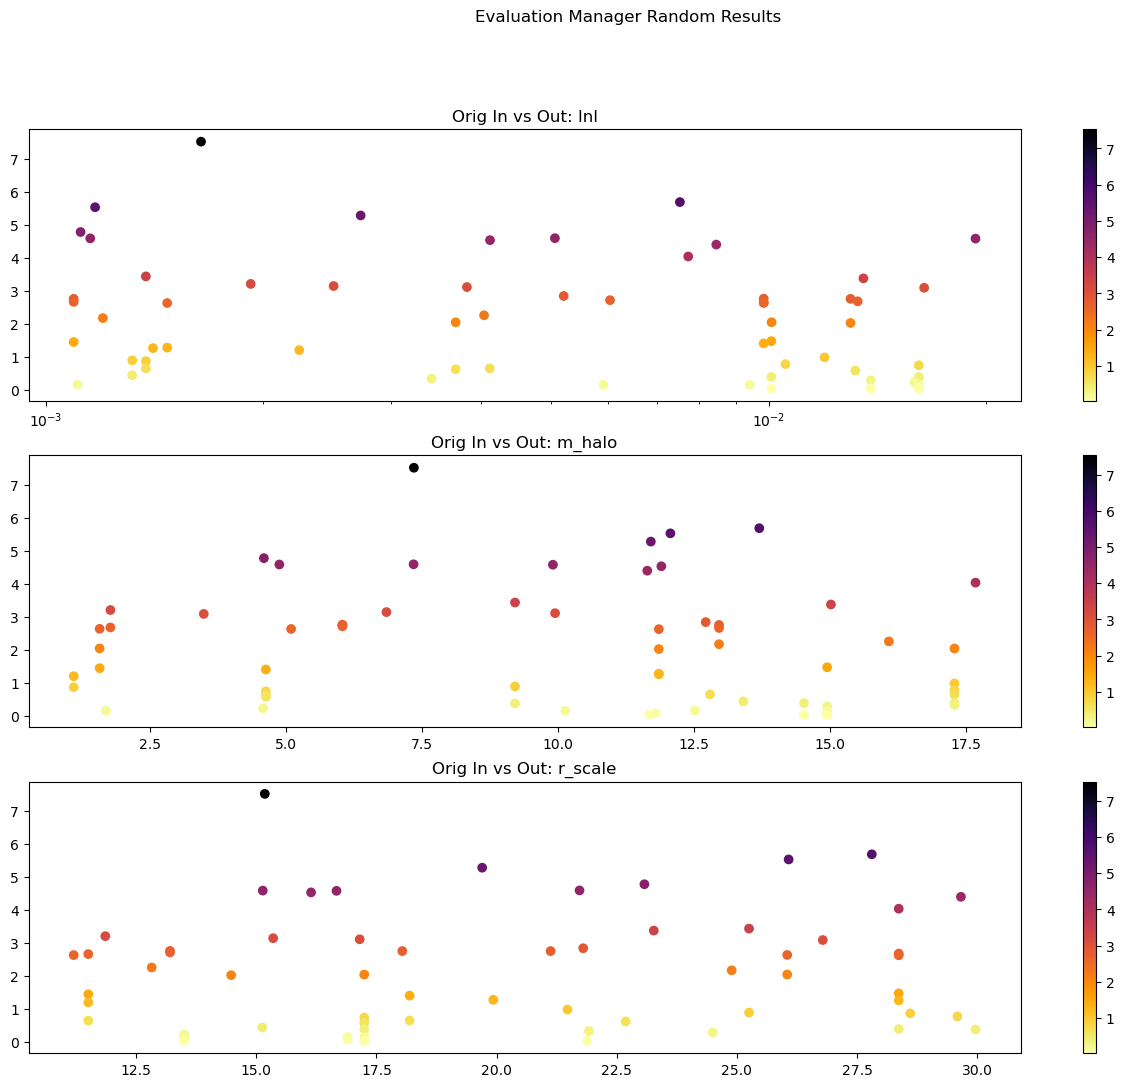

In [11]:
if buildEnv:
    
    # Create subplot for each dimension
    fig, axs = plt.subplots(3, figsize=(16, 12))

    # Set main title
    fig.suptitle("Evaluation Manager Random Results")

    # Histogram of inputs and outputs
    for i, dim_info in enumerate(space_manager.space_info):
        # inputs
        exec_manager.scatter_input(dim_index=i, space='original', external_ax=axs[i], title=f"Orig In vs Out: {dim_info['name']}", reverse_color=True)
